In [1]:
import pandas as pd
import hbsir

In [124]:
house_specifications = hbsir.load_table("house_specifications", 1402)
house_specifications.head()

,ID,Dwelling_Type,Other_Dwelling_Types,Tenure,Number_of_Rooms,House_Area,Structure_Type,Structure_Main_Materials,Car,Motorcycle,...,Central_AC,Central_Heating,Water_Heater,Split_AC,Sewerage,Elevator,Cooking_Fuel,Heating_Fuel,Hotwater_Fuel,Year
0,20001383933,Non_Apartment_Unit,<NA>,Owned_Estate_Land,3,85,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402
1,20001383935,Non_Apartment_Unit,<NA>,Owned_Estate_Land,3,55,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,True,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402
2,20001383938,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,75,Other,Adobe_and_Clay,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402
3,20001383941,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,100,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402
4,20001383944,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,100,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402


In [125]:
members_properties = hbsir.load_table("members_properties", 1402)
members_properties.head()

,Year,ID,Member_Number,Relationship,Sex,Age,Is_Literate,Is_Student,Education_Level,Marital_Status,Activity_Status
0,1402,20001383933,1,Head,Male,66,True,False,Primary,Married,Income_without_Work
1,1402,20001383933,2,Spouse,Female,59,False,<NA>,NaN,Married,Housekeeper
2,1402,20001383935,1,Head,Male,46,True,False,Primary,Married,Employed
3,1402,20001383935,2,Spouse,Female,42,True,False,Lower_Secondary,Married,Housekeeper
4,1402,20001383935,3,Child,Male,16,True,False,Lower_Secondary,Bachelor,Unemployed


In [126]:
heads_df = members_properties[members_properties['Relationship'] == 'Head']
heads_df.head()

,Year,ID,Member_Number,Relationship,Sex,Age,Is_Literate,Is_Student,Education_Level,Marital_Status,Activity_Status
0,1402,20001383933,1,Head,Male,66,True,False,Primary,Married,Income_without_Work
2,1402,20001383935,1,Head,Male,46,True,False,Primary,Married,Employed
6,1402,20001383938,1,Head,Male,86,False,<NA>,NaN,Widowed,Income_without_Work
7,1402,20001383941,1,Head,Female,69,True,False,Lower_Secondary,Widowed,Income_without_Work
8,1402,20001383944,1,Head,Female,90,False,<NA>,NaN,Widowed,Income_without_Work


In [127]:
heads_df = heads_df[['ID', 'Education_Level']]
heads_df.head()

,ID,Education_Level
0,20001383933,Primary
2,20001383935,Primary
6,20001383938,NaN
7,20001383941,Lower_Secondary
8,20001383944,NaN


In [128]:
household_df = house_specifications.merge(heads_df, on='ID', how='left')
household_df.head()

,ID,Dwelling_Type,Other_Dwelling_Types,Tenure,Number_of_Rooms,House_Area,Structure_Type,Structure_Main_Materials,Car,Motorcycle,...,Central_Heating,Water_Heater,Split_AC,Sewerage,Elevator,Cooking_Fuel,Heating_Fuel,Hotwater_Fuel,Year,Education_Level
0,20001383933,Non_Apartment_Unit,<NA>,Owned_Estate_Land,3,85,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary
1,20001383935,Non_Apartment_Unit,<NA>,Owned_Estate_Land,3,55,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,True,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary
2,20001383938,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,75,Other,Adobe_and_Clay,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,NaN
3,20001383941,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,100,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Lower_Secondary
4,20001383944,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,100,Other,Brick_and_Iron_or_Stone_and_Iron,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,NaN


In [81]:
household_df = hbsir.add_attribute(household_df, name="Urban_Rural")
household_df = household_df.loc[(household_df["Urban_Rural"] == "Urban")]
household_df.head()

,ID,Dwelling_Type,Other_Dwelling_Types,Tenure,Number_of_Rooms,House_Area,Structure_Type,Structure_Main_Materials,Car,Motorcycle,...,Water_Heater,Split_AC,Sewerage,Elevator,Cooking_Fuel,Heating_Fuel,Hotwater_Fuel,Year,Education_Level,Urban_Rural
18243,12309287331,Apartment_Unit,<NA>,Owned_Estate_Land,4,70,Metal,NaN,<NA>,<NA>,...,<NA>,<NA>,True,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Pre_University,Urban
18244,12309287335,Apartment_Unit,<NA>,Mortgage,4,95,Metal,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary,Urban
18245,12309287338,Apartment_Unit,<NA>,Rent,4,90,Metal,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,NaN,Urban
18246,12309287341,Non_Apartment_Unit,<NA>,Owned_Estate_Land,4,85,Metal,NaN,True,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary,Urban
18247,12309287344,Apartment_Unit,<NA>,Mortgage,3,55,Metal,NaN,True,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary,Urban


In [129]:
household_df = hbsir.add_attribute(household_df, name="Province")
household_df = household_df.loc[(household_df["Province"] == "Tehran")]
household_df.head()

,ID,Dwelling_Type,Other_Dwelling_Types,Tenure,Number_of_Rooms,House_Area,Structure_Type,Structure_Main_Materials,Car,Motorcycle,...,Water_Heater,Split_AC,Sewerage,Elevator,Cooking_Fuel,Heating_Fuel,Hotwater_Fuel,Year,Education_Level,Province
3455,22301631336,Apartment_Unit,<NA>,Owned_Estate_Land,3,80,Metal,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Lower_Secondary,Tehran
3456,22301631338,Apartment_Unit,<NA>,Owned_Estate_Land,4,110,Metal,NaN,True,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Lower_Secondary,Tehran
3457,22301631341,Apartment_Unit,<NA>,Owned_Estate_Land,4,100,Metal,NaN,True,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Lower_Secondary,Tehran
3458,22301631344,Apartment_Unit,<NA>,Owned_Estate_Land,3,50,Metal,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary,Tehran
3459,22301631347,Apartment_Unit,<NA>,Mortgage,3,50,Metal,NaN,True,<NA>,...,<NA>,<NA>,<NA>,<NA>,Piped_Gas,Piped_Gas,Piped_Gas,1402,Primary,Tehran


In [130]:
household_df = hbsir.add_weight(household_df)[['ID', 'Tenure' ,'Education_Level', 'Weight']]

household_df.head()

,ID,Tenure,Education_Level,Weight
3455,22301631336,Owned_Estate_Land,Lower_Secondary,398.297959
3456,22301631338,Owned_Estate_Land,Lower_Secondary,398.297959
3457,22301631341,Owned_Estate_Land,Lower_Secondary,398.297959
3458,22301631344,Owned_Estate_Land,Primary,398.297959
3459,22301631347,Mortgage,Primary,398.297959


In [131]:
pd.crosstab(household_df['Education_Level'], household_df['Tenure'], normalize='index')


Tenure,Owned_Estate_Land,Owned_Estate,Rent,Mortgage,Service,Free
Education_Level,,,,,,
Primary,0.639485,0.006438,0.120172,0.165236,0.019313,0.049356
Lower_Secondary,0.601208,0.003021,0.129909,0.163142,0.021148,0.081571
Higher_Secondary,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pre_University,0.573892,0.002463,0.162562,0.165025,0.017241,0.078818
Short_Cycle_Tertiary,0.721311,0.000000,0.081967,0.131148,0.000000,0.065574
Bachelors,0.556180,0.000000,0.196629,0.129213,0.044944,0.073034
Masters,0.517647,0.000000,0.129412,0.164706,0.141176,0.047059
Doctoral,0.777778,0.000000,0.055556,0.000000,0.111111,0.055556
Unofficial,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000


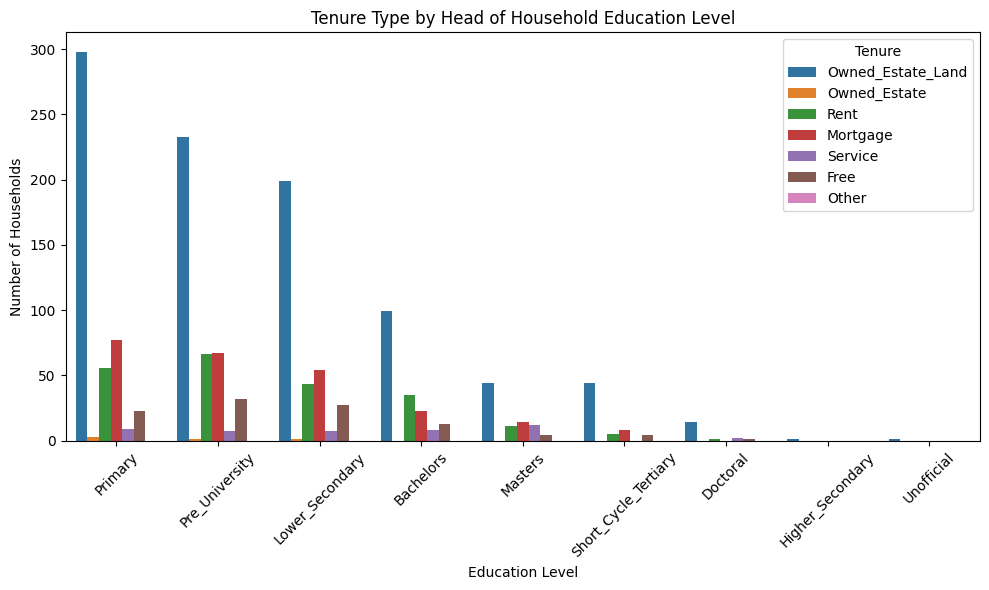

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(
    data=household_df,
    x='Education_Level',
    hue='Tenure',
    order=household_df['Education_Level'].value_counts().index
)
plt.xticks(rotation=45)
plt.title('Tenure Type by Head of Household Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Households')
plt.legend(title='Tenure')
plt.tight_layout()
plt.show()


In [134]:
import pandas as pd

df = household_df.dropna(subset=['Education_Level', 'Tenure'])

df.head()

,ID,Tenure,Education_Level,Weight
3455,22301631336,Owned_Estate_Land,Lower_Secondary,398.297959
3456,22301631338,Owned_Estate_Land,Lower_Secondary,398.297959
3457,22301631341,Owned_Estate_Land,Lower_Secondary,398.297959
3458,22301631344,Owned_Estate_Land,Primary,398.297959
3459,22301631347,Mortgage,Primary,398.297959


In [87]:
# جمع وزن‌ها برای هر ترکیب تحصیلات و مالکیت
weighted_counts = df.groupby(['Education_Level', 'Tenure'], observed=True)['Weight'].sum().reset_index()

# مجموع وزن‌ها برای هر سطح تحصیلات
total_weights = weighted_counts.groupby('Education_Level', observed=True)['Weight'].sum().reset_index(name='Total_Weight')

# Merge back
weighted_counts = weighted_counts.merge(total_weights, on='Education_Level')

# Compute weighted proportions
weighted_counts['Proportion'] = weighted_counts['Weight'] / weighted_counts['Total_Weight']

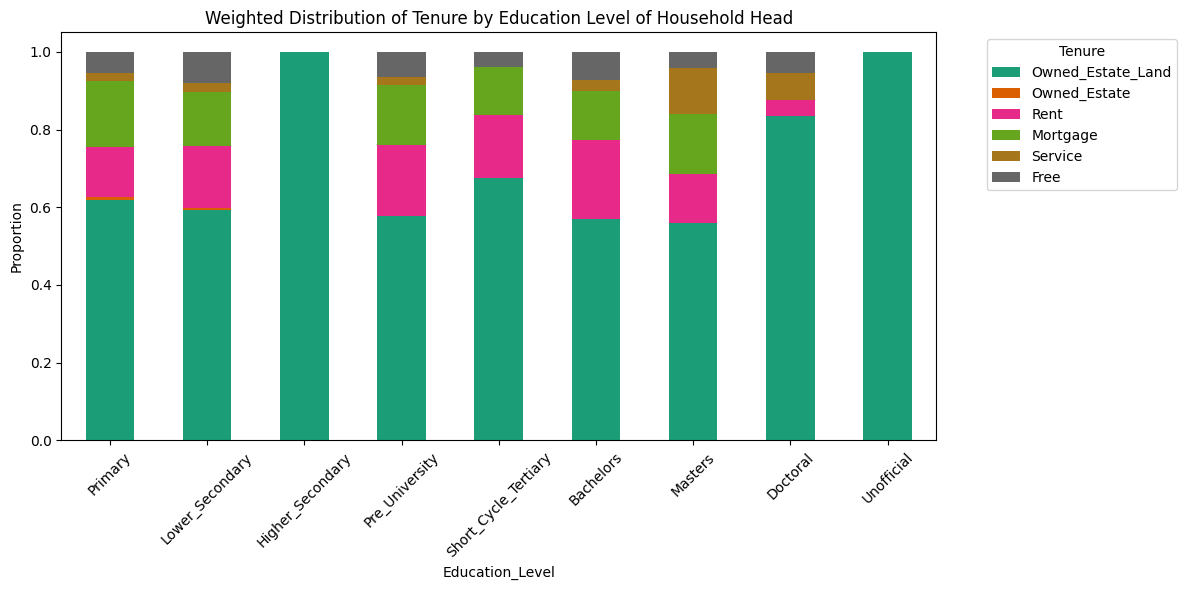

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot for stacked bar chart
plot_df = weighted_counts.pivot(index='Education_Level', columns='Tenure', values='Proportion').fillna(0)

# Plot
plot_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Dark2')

plt.ylabel('Proportion')
plt.title('Weighted Distribution of Tenure by Education Level of Household Head')
plt.xticks(rotation=45)
plt.legend(title='Tenure', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


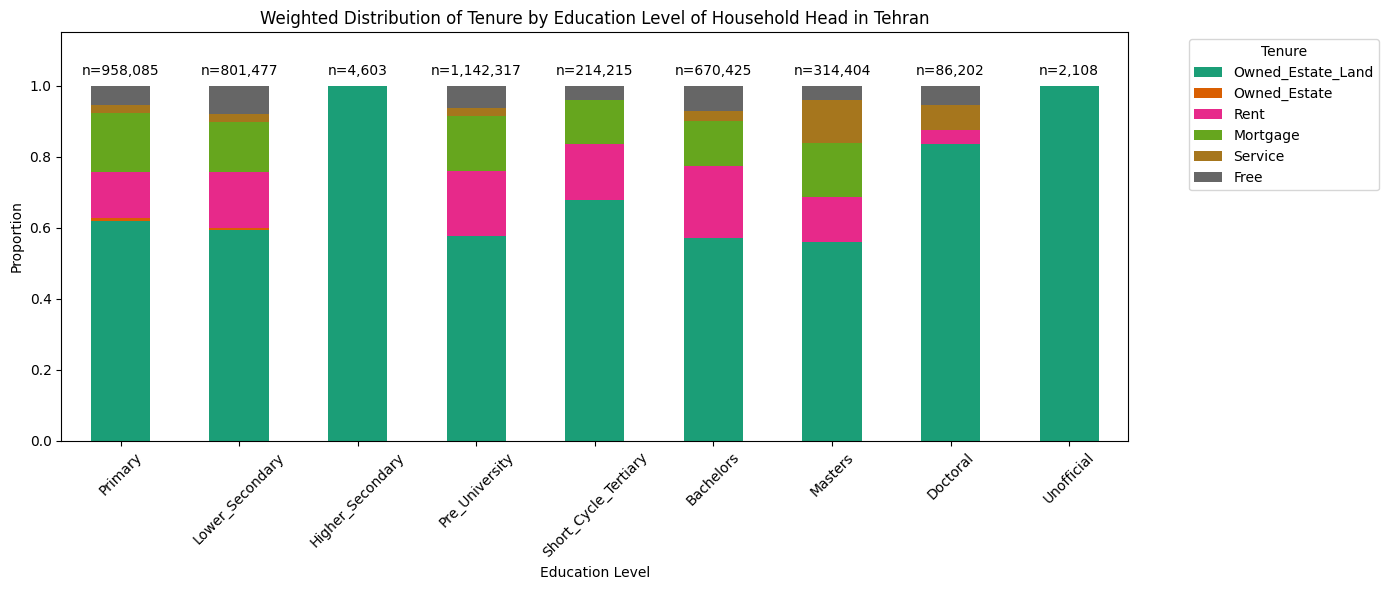

In [159]:
import matplotlib.pyplot as plt

# Create the same stacked bar plot
plot_df = weighted_counts.pivot(index='Education_Level', columns='Tenure', values='Proportion').fillna(0)

ax = plot_df.plot(kind='bar', stacked=True, figsize=(14,6), colormap='Dark2')
plt.title('Weighted Distribution of Tenure by Education Level of Household Head in Tehran')
plt.ylabel('Proportion')
plt.xlabel('Education Level')
plt.xticks(rotation=45)
plt.legend(title='Tenure', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add text labels (sample size) above each bar
for i, label in enumerate(plot_df.index):
    size = total_weights.loc[total_weights['Education_Level'] == label, 'Total_Weight'].values[0]
    plt.text(i, 1.02, f'n={int(size):,}', ha='center', va='bottom', fontsize=10, color='black')


plt.ylim(0, 1.15)  # Make space for labels
plt.tight_layout()
plt.show()


In [146]:
table = hbsir.load_table("household_information", 1402)
table.head()

,Year,ID,Season,Weight,Household_Type,Main_Household,Alternative_Household
0,1402,20001384232,Spring,165.931263,Normal,True,<NA>
1,1402,20001384233,Spring,165.931263,Normal,True,<NA>
2,1402,20001384241,Spring,165.931263,Normal,False,True
3,1402,20001384242,Spring,165.931263,Normal,True,<NA>
4,1402,20001384244,Spring,165.931263,Normal,False,True


In [149]:
table['Weight'].sum()

np.float64(27697667.999999978)

In [150]:
table = hbsir.add_attribute(table, name="Urban_Rural")
table.head()

,Year,ID,Season,Weight,Household_Type,Main_Household,Alternative_Household,Urban_Rural
0,1402,20001384232,Spring,165.931263,Normal,True,<NA>,Rural
1,1402,20001384233,Spring,165.931263,Normal,True,<NA>,Rural
2,1402,20001384241,Spring,165.931263,Normal,False,True,Rural
3,1402,20001384242,Spring,165.931263,Normal,True,<NA>,Rural
4,1402,20001384244,Spring,165.931263,Normal,False,True,Rural


In [154]:
table = hbsir.add_attribute(table, name="Province")
table.head()

,Year,ID,Season,Weight,Household_Type,Main_Household,Alternative_Household,Urban_Rural,Province
0,1402,20001384232,Spring,165.931263,Normal,True,<NA>,Rural,Markazi
1,1402,20001384233,Spring,165.931263,Normal,True,<NA>,Rural,Markazi
2,1402,20001384241,Spring,165.931263,Normal,False,True,Rural,Markazi
3,1402,20001384242,Spring,165.931263,Normal,True,<NA>,Rural,Markazi
4,1402,20001384244,Spring,165.931263,Normal,False,True,Rural,Markazi


In [152]:
table[table['Urban_Rural'] == 'Urban']['Weight'].sum()

np.float64(21552544.999999974)

In [155]:
table[(table["Urban_Rural"] == "Urban") & (table["Province"] == "Tehran")]['Weight'].sum()

np.float64(4629337.9999999935)

In [158]:
total_weights['Total_Weight'].sum()

np.float64(4193840.3811294213)

In [11]:
filt = (table["Urban_Rural"] == "Urban") & (table["Province"] == "Tehran")
table = table.loc[filt]
table.head()

,Year,ID,Table_Name,Commodity_Code,Provision_Method,Amount,Price,Gross_Expenditure,Net_Expenditure,Urban_Rural,Province
624297,1401,12301265526,food,11143,Purchase,24.0,65000.0,1560000.0,1560000.0,Urban,Tehran
624298,1401,12301265526,food,11151,Purchase,72.0,55000.0,3960000.0,3960000.0,Urban,Tehran
624299,1401,12301265526,food,11171,Purchase,12.0,600000.0,7200000.0,7200000.0,Urban,Tehran
624300,1401,12301265526,food,11211,Purchase,18.0,1850000.0,33300000.0,33300000.0,Urban,Tehran
624301,1401,12301265526,food,11231,Purchase,72.0,380000.0,27360000.0,27360000.0,Urban,Tehran


In [12]:
table = hbsir.add_classification(
    table,
    name="original",
    levels=2,
    column_names="COICOP",
)
table.head()

,Year,ID,Table_Name,Commodity_Code,Provision_Method,Amount,Price,Gross_Expenditure,Net_Expenditure,Urban_Rural,Province,COICOP
624297,1401,12301265526,food,11143,Purchase,24.0,65000.0,1560000.0,1560000.0,Urban,Tehran,food
624298,1401,12301265526,food,11151,Purchase,72.0,55000.0,3960000.0,3960000.0,Urban,Tehran,food
624299,1401,12301265526,food,11171,Purchase,12.0,600000.0,7200000.0,7200000.0,Urban,Tehran,food
624300,1401,12301265526,food,11211,Purchase,18.0,1850000.0,33300000.0,33300000.0,Urban,Tehran,food
624301,1401,12301265526,food,11231,Purchase,72.0,380000.0,27360000.0,27360000.0,Urban,Tehran,food


In [13]:
total_expenditure = table.groupby(["Year", "ID"])["Gross_Expenditure"].sum()
total_expenditure = total_expenditure.rename("Total_Expenditure")
total_expenditure.head()

Year  ID         
1401  12301265430    4411560000.0
      12301265433    1263400000.0
      12301265436    5604360000.0
      12301265438     597250000.0
      12301265441    8787720000.0
Name: Total_Expenditure, dtype: Float64

In [15]:
filt = table["COICOP"] == "actual_rentals_for_housing"
rental_expenditure = table.loc[filt].groupby(["Year", "ID"])["Gross_Expenditure"].sum()
rental_expenditure = rental_expenditure.rename("Rental_Expenditure")
rental_expenditure.head()

Year  ID         
1401  12301265541     420000000.0
      12301265732    1800000000.0
      12301265834     780000000.0
      12301265932    1200000000.0
      12301265938    2400000000.0
Name: Rental_Expenditure, dtype: Float64

In [16]:
expenditure_table = pd.concat([total_expenditure, rental_expenditure], axis="columns")
expenditure_table = expenditure_table.fillna(0)
expenditure_table.head()

Total_Expenditure  Rental_Expenditure
Year ID                                                
1401 12301265430       4411560000.0                 0.0
     12301265433       1263400000.0                 0.0
     12301265436       5604360000.0                 0.0
     12301265438        597250000.0                 0.0
     12301265441       8787720000.0                 0.0

In [17]:
expenditure_table = hbsir.add_weight(expenditure_table)
expenditure_table.head()

Total_Expenditure  Rental_Expenditure       Weight
Year ID                                                             
1401 12301265430       4411560000.0                 0.0  3752.561959
     12301265433       1263400000.0                 0.0  3752.561959
     12301265436       5604360000.0                 0.0  3752.561959
     12301265438        597250000.0                 0.0  3752.561959
     12301265441       8787720000.0                 0.0  3752.561959

In [18]:
expenditure_table = hbsir.calculate.add_decile(
    expenditure_table,
    on_variable="Income",
    equivalence_scale="OECD_Modified",
    groupby=["Urban_Rural", "Province"],
)
expenditure_table.head()

Total_Expenditure  Rental_Expenditure       Weight  Decile
Year ID                                                                     
1401 12301265430       4411560000.0                 0.0  3752.561959      10
     12301265433       1263400000.0                 0.0  3752.561959       3
     12301265436       5604360000.0                 0.0  3752.561959      10
     12301265438        597250000.0                 0.0  3752.561959       6
     12301265441       8787720000.0                 0.0  3752.561959      10